# 🧑‍💼 HR Analytics — Employee Attrition Analysis

**Author:** Ravi Prakash

**Tool:** Python (Google Colab)  
**Libraries:** Pandas, NumPy, Seaborn, Matplotlib

---

## 📌 Problem Statement

A company is facing a serious issue of **employee attrition** — employees are resigning at a high rate.  
This is affecting business operations — deadlines are being missed and projects are left incomplete due to loss of experienced staff.

The HR department has surveyed employees across various departments and collected data.  
**As the analyst, our job is to explore this data and find out the key reasons behind employee attrition.**

---

## 📂 Dataset Overview

| Column | Description |
|---|---|
| satisfactoryLevel | Employee satisfaction score (0 to 1) |
| lastEvaluation | Last performance review score (0 to 1) |
| numberOfProjects | Number of projects assigned |
| avgMonthlyHours | Average hours worked per month |
| timeSpent.company | Years spent in the company |
| workAccident | Whether a work accident occurred (0/1) |
| left | Whether employee left (1) or stayed (0) — **Target Column** |
| promotionInLast5years | Promoted in last 5 years (0/1) |
| dept | Department name |
| salary | Salary level — low / medium / high |

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving employe.csv to employe.csv


## Step 1 — Import Libraries & Load Data

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("employe.csv")

## Step 2 — First Look at the Data

We start by viewing a sample of the data and checking its structure — column names, data types, and row count.

In [ ]:
df.head()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfactoryLevel      14999 non-null  float64
 1   lastEvaluation         14999 non-null  float64
 2   numberOfProjects       14999 non-null  int64  
 3   avgMonthlyHours        14999 non-null  int64  
 4   timeSpent.company      14999 non-null  int64  
 5   workAccident           14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotionInLast5years  14999 non-null  int64  
 8   dept                   14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


## Step 3 — Exploring Key Columns

Before analysis, we check the unique values in important columns to understand what kind of data we're working with.  
This helps us spot any unexpected values or typos early.

In [ ]:
df.columns


Index(['satisfactoryLevel', 'lastEvaluation', 'numberOfProjects',
       'avgMonthlyHours', 'timeSpent.company', 'workAccident', 'left',
       'promotionInLast5years', 'dept', 'salary'],
      dtype='object')

In [ ]:
df.shape

(14999, 10)

In [ ]:
df['numberOfProjects'].unique()

array([2, 5, 7, 6, 4, 3])

In [ ]:
df['numberOfProjects'].value_counts()

,count
numberOfProjects,
4,4365
3,4055
5,2761
2,2388
6,1174
7,256


In [ ]:
df['workAccident'].unique()

array([0, 1])

In [ ]:
df['promotionInLast5years'].unique()

array([0, 1])

In [ ]:
df['dept'].value_counts()


,count
dept,
sales,4140
technical,2720
support,2229
IT,1227
product_mng,902
marketing,858
RandD,787
accounting,767
hr,739


In [ ]:
df['salary'].value_counts()

,count
salary,
low,7316
medium,6446
high,1237


In [ ]:
df['left'].unique()

array([1, 0])

## Step 4 — Data Cleaning

We check for **missing values** and **duplicate rows**.  
Dirty data leads to wrong conclusions — so cleaning is always done before any analysis.

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(3008)

In [ ]:
df.drop_duplicates(inplace=True)
df.shape

(11991, 10)

## Step 5 — Analysis & Visualisation

Now we explore each factor that might be causing employees to leave.

### 📌 Insight — Employee Turnover Distribution

Out of ~15,000 employees surveyed, roughly **24% have left** the company.  
This is a significant attrition rate and confirms the problem is real and needs attention.


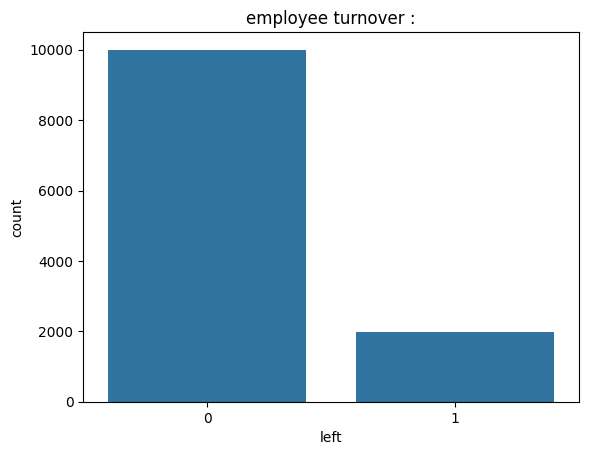

In [ ]:
sns.countplot(x='left',data=df)
plt.title("employee turnover :")
plt.show()

### Chart 1 — Number of Projects vs Attrition

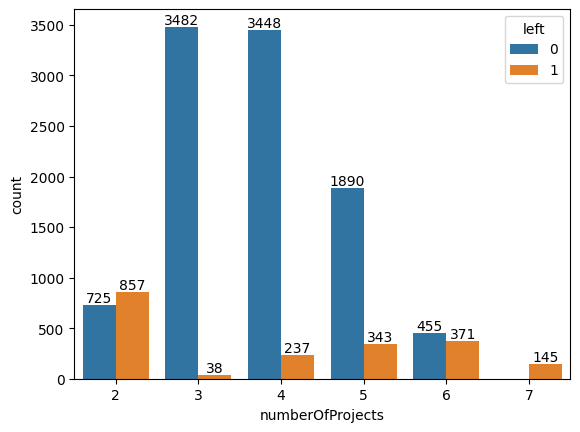

In [ ]:
x1=sns.countplot(x='numberOfProjects',data=df,hue='left')
x1.bar_label(x1.containers[0])
x1.bar_label(x1.containers[1])
plt.show()

### 📌 Insight — Number of Projects

- Employees with **2 projects** show high attrition — they feel **underutilised** and bored.
- Employees with **3–5 projects** have the lowest attrition — this is the healthy workload range.
- Employees with **6–7 projects** show very high attrition — they are **overloaded and burned out**.

➡️ HR should ensure workload stays in the 3–5 project range per employee.

### Chart 2 — Promotion vs Attrition

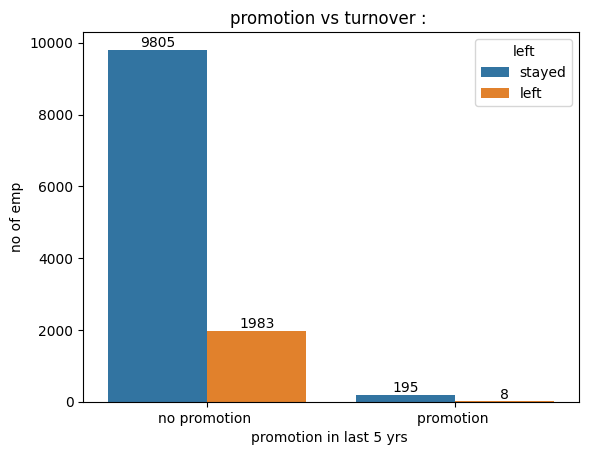

In [ ]:
x2=sns.countplot(x='promotionInLast5years',data=df,hue='left')
x2.bar_label(x2.containers[0])
x2.bar_label(x2.containers[1])
plt.title("promotion vs turnover : ")
plt.xlabel("promotion in last 5 yrs ")
plt.ylabel("no of emp")
plt.xticks([0,1],["no promotion ","promotion "])
# plt.legend()
plt.legend(title='left',labels=["stayed","left"])
plt.show()

### 📌 Insight — Promotion in Last 5 Years

The vast majority of employees who left had **received no promotion in 5 years**.  
Lack of career growth is one of the strongest signals of attrition in this dataset.

➡️ HR must review the promotion and appraisal policy — employees need to see a career path.

### Chart 3 — Years Spent in Company vs Attrition

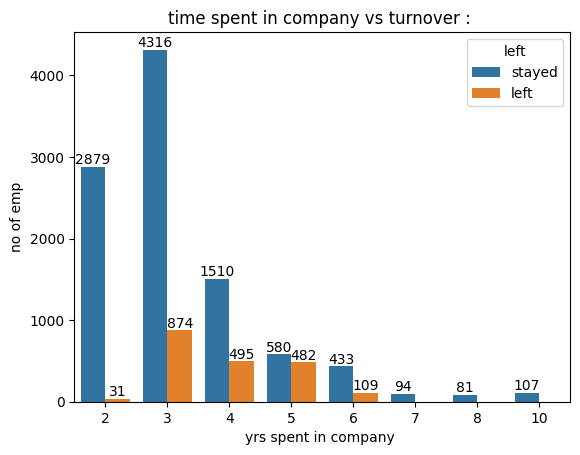

In [ ]:
x3=sns.countplot(x="timeSpent.company",data=df,hue="left")
x3.bar_label(x3.containers[0])
x3.bar_label(x3.containers[1])
plt.xlabel("yrs spent in company ")
plt.ylabel("no of emp")
plt.title("time spent in company vs turnover : ")
plt.legend(title="left",labels=["stayed","left"])
plt.show()


### 📌 Insight — Employee Tenure

- **2–3 year employees** leave the most — they have gained enough experience and start seeking better opportunities.
- **Freshers (0–1 year)** tend to stay to build experience.
- **Senior employees (7+ years)** are comfortable and mostly stay.

➡️ The 3–5 year mark is the most critical retention window for HR to focus on.

### Deep Dive — Employees Who Got Promoted But Still Left

This is an interesting group — they received a promotion yet still resigned.  
We filter them out to understand what else drove them away.

In [ ]:
df1 = df[(df['promotionInLast5years'] == 1) & (df['left'] == 1)]
df1

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
52,0.79,0.59,4,139,3,0,1,1,management,low
189,0.11,0.79,6,292,4,0,1,1,technical,low
386,0.41,0.56,2,154,3,0,1,1,support,medium
1131,0.44,0.55,2,128,3,0,1,1,IT,medium
7980,0.45,0.51,2,160,3,1,1,1,sales,low
8085,0.41,0.46,2,160,3,0,1,1,sales,low
8469,0.46,0.45,2,138,3,0,1,1,IT,low
14530,0.87,1.00,4,258,5,1,1,1,sales,medium


### 📌 Insight — Promoted but Still Left

Even among promoted employees who left, we see a pattern:  
- Many had **very high average monthly hours** (overworked even after promotion)
- Several had **low satisfaction scores** despite the promotion
- Some were handling **6–7 projects** simultaneously

➡️ Promotion alone is not enough. If workload and satisfaction are not addressed, employees will still leave.

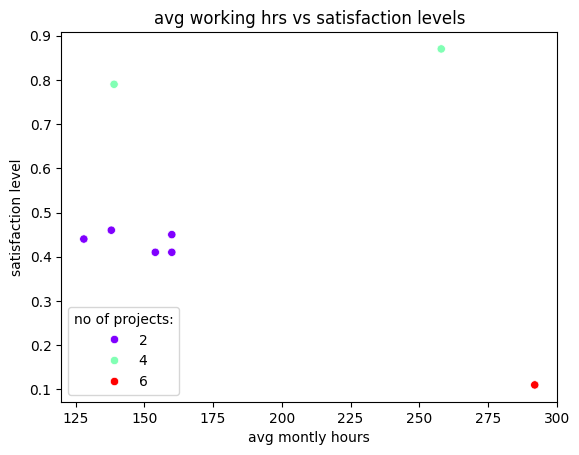

In [ ]:
sns.scatterplot(x='avgMonthlyHours',y="satisfactoryLevel",hue="numberOfProjects",data=df1,palette="rainbow")
plt.title("avg working hrs vs satisfaction levels")
plt.xlabel("avg montly hours")
plt.ylabel("satisfaction level")
plt.legend(title="no of projects:")
plt.show()

### Chart 4 — Salary Level vs Attrition

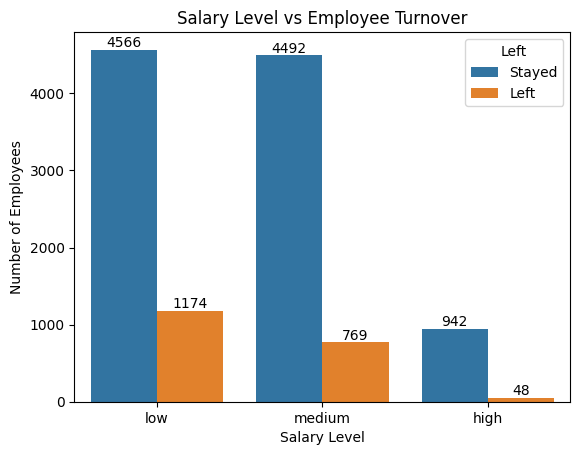

In [ ]:
x4 = sns.countplot(x='salary', hue='left', data=df, order=['low','medium','high'])
x4.bar_label(x4.containers[0])
x4.bar_label(x4.containers[1])
plt.title("Salary Level vs Employee Turnover")
plt.xlabel("Salary Level")
plt.ylabel("Number of Employees")
plt.legend(title="Left", labels=["Stayed", "Left"])
plt.show()

### 📌 Insight — Salary

- **Low salary** employees have the highest attrition — financial dissatisfaction is a direct trigger.
- Even **medium salary** employees show notable attrition — they may feel underpaid relative to their workload.
- **High salary** employees mostly stay.

➡️ HR should benchmark salaries against industry standards, especially for low and medium bands.

### Chart 5 — Satisfaction Level Distribution (Stayed vs Left)

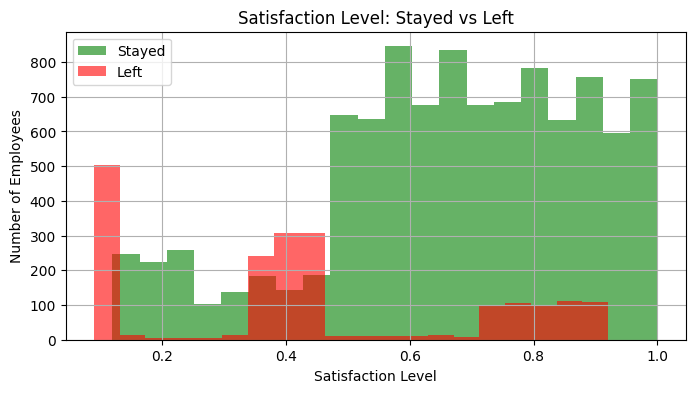

In [ ]:
plt.figure(figsize=(8, 4))
df[df['left'] == 0]['satisfactoryLevel'].hist(alpha=0.6, label='Stayed', color='green', bins=20)
df[df['left'] == 1]['satisfactoryLevel'].hist(alpha=0.6, label='Left', color='red', bins=20)
plt.title("Satisfaction Level: Stayed vs Left")
plt.xlabel("Satisfaction Level")
plt.ylabel("Number of Employees")
plt.legend()
plt.show()

### 📌 Insight — Satisfaction Level

- Employees who left cluster at **very low satisfaction (0.1–0.35)** — clearly unhappy employees.
- Surprisingly, some employees with **high satisfaction (0.7–0.9) also left** — possibly poached by better offers.
- Employees who stayed are mostly in the **mid-to-high satisfaction** range.

➡️ Satisfaction score is the single strongest predictor of attrition. Regular employee feedback surveys are critical.

## Step 6 — Attrition Risk Segmentation

We now build a **custom risk score** for each employee based on multiple factors:
- Low satisfaction → +2 points
- Too many projects (6+) → +2 points
- No promotion → +1 point
- Low salary → +2 points
- Overworked (249+ hrs/month) → +1 point

Employees are then categorised as **Low / Medium / High Risk** using these scores.

In [ ]:
df["risk_score"]=0

In [ ]:
df.head()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary,risk_score
0,0.38,0.53,2,157,3,0,1,0,sales,low,0
1,0.80,0.86,5,262,6,0,1,0,sales,medium,0
2,0.11,0.88,7,272,4,0,1,0,sales,medium,0
3,0.37,0.52,2,159,3,0,1,0,sales,low,0
4,0.41,0.50,2,153,3,0,1,0,sales,low,0


In [ ]:
df.loc[df["satisfactoryLevel"]<0.4,"risk_score"] +=2
df.loc[df["numberOfProjects"]>6,"risk_score"] +=2
df.loc[df["promotionInLast5years"] ==0,"risk_score"] +=1
df.loc[df["salary"] =="low" ,"risk_score"] +=2
df.loc[df["avgMonthlyHours"] > 249 ,"risk_score"] +=1

In [ ]:
df['risk_category'] = pd.cut(df['risk_score'],
                              bins=[-1, 1, 3, 8],
                              labels=['Low Risk', 'Medium Risk', 'High Risk'])

In [ ]:
df.head()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary,risk_score,risk_category
0,0.38,0.53,2,157,3,0,1,0,sales,low,5,High Risk
1,0.80,0.86,5,262,6,0,1,0,sales,medium,2,Medium Risk
2,0.11,0.88,7,272,4,0,1,0,sales,medium,6,High Risk
3,0.37,0.52,2,159,3,0,1,0,sales,low,5,High Risk
4,0.41,0.50,2,153,3,0,1,0,sales,low,3,Medium Risk


/tmp/ipykernel_28752/4252925355.py:1: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.countplot(x='risk_category', hue='left', data=df,


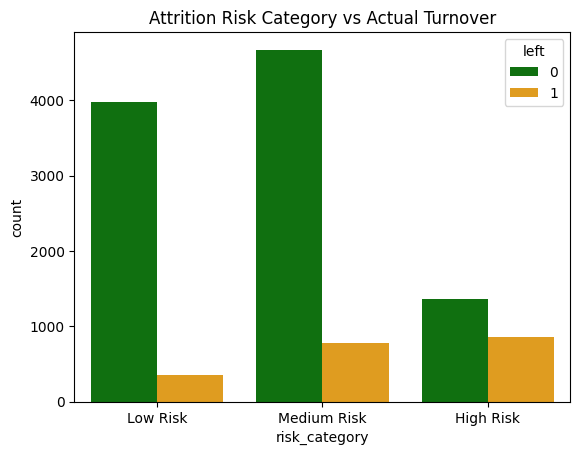

In [ ]:

sns.countplot(x='risk_category', hue='left', data=df,
              palette=['green','orange','red'])
plt.title("Attrition Risk Category vs Actual Turnover")
plt.show()

### 📌 Insight — Risk Segmentation

Employees labelled **High Risk** show significantly higher actual attrition — validating our scoring model.  
This kind of segmentation can help HR **proactively identify** employees likely to leave before they resign.

---

## ✅ Final Conclusions & Recommendations

| # | Finding | Recommendation |
|---|---------|---------------|
| 1 | Low satisfaction is the #1 attrition driver | Conduct quarterly satisfaction surveys |
| 2 | Most employees who left had no promotion in 5 years | Reform promotion & appraisal policy |
| 3 | Employees on 6–7 projects are heavily overloaded | Cap projects at 5 per employee |
| 4 | Low salary employees leave the most | Benchmark and revise salary structure |
| 5 | 3–5 year tenure is the highest-risk window | Create retention programs for mid-tenure staff |
| 6 | Even promoted employees leave if overworked | Pair promotions with workload reduction |

---
## Business Recommendations

- Introduce regular employee feedback system
- Provide structured promotion cycles
- Monitor high-risk employees using risk score


*This analysis was performed as part of an HR Analytics case study using Python (EDA).*